# Amazon Beauty RQ-VAE pipeline

End-to-end run on the Amazon Product Reviews (Beauty) dataset:
1. Build embeddings (sentence-t5-base, 768d)
2. Train the RQ-VAE
3. Generate Semantic IDs

All artifacts land under `outputs/amazon_beauty_*` because `name: amazon_beauty` in the config drives the paths.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import sys
from pathlib import Path

# Absolute path of your local rq-vae/ checkout. Hardcoded because some
# Jupyter setups run with cwd=/tmp, so detecting via Path.cwd() doesn't work.
ROOT = Path("/content/drive/MyDrive/tiger/rq-vae")
assert (ROOT / "src" / "amazon_beauty_dataloader.py").exists(), f"bad ROOT: {ROOT}"

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CONFIG = str(ROOT / "amazon_beauty_config.yaml")

## 1. Build embeddings

In [4]:
from src.amazon_beauty_dataloader import prepare
from src.config import load_config

cfg = load_config(CONFIG)
prepare(cfg, download=True)

[data] already downloaded at data/amazon/meta_Beauty.json.gz
[data] loaded 259204 beauty items
[data] loading embedding model: sentence-transformers/sentence-t5-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.78k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

[data] encoding 259204 item texts


Batches:   0%|          | 0/8101 [00:00<?, ?it/s]

[data] wrote outputs/amazon_beauty_embeddings.npy  shape=(259204, 768) dtype=float32
[data] wrote outputs/amazon_beauty_stats.npz
[data] wrote outputs/amazon_beauty_items.csv


## 2. Train the RQ-VAE

In [5]:
from src.train import train

# Reinit dead codes every 1000 steps instead of the config default (250).
# ~253 steps/epoch here, so this fires roughly once every 4 epochs.
cfg["train"]["reinit_every"] = 1000

history = train(cfg)

[train] device=cuda
[train] loaded embeddings (259204, 768)
[train] model L=3  K=256  D=32
[train] k-means init done on full corpus (259204 latents)
[train] epoch   1/20000  loss=31600319526693536.0000  recon=31600290914353492.0000  rq=27902057357.8869  util=['0.01', '0.04', '0.05']  ppl=['2.0', '5.2', '6.3']  uniq=0.000
[train] epoch   2/20000  loss=27411323654.7910  recon=27392122834.7661  rq=19200921.7694  util=['0.02', '0.07', '0.09']  ppl=['2.9', '7.8', '12.9']  uniq=0.002
[train] epoch   3/20000  loss=5601896744.2917  recon=5591249596.9393  rq=10647156.9915  util=['0.02', '0.12', '0.14']  ppl=['3.6', '11.5', '25.6']  uniq=0.007
[train] step 1000: reinit [250, 222, 206] dead codes per level
[train] epoch   4/20000  loss=3575952370.2679  recon=3568789779.8120  rq=7162596.0719  util=['1.00', '0.71', '0.70']  ppl=['211.7', '39.1', '47.0']  uniq=0.357
[train] epoch   5/20000  loss=3384221098.9366  recon=3384158725.8547  rq=62369.3887  util=['1.00', '0.66', '0.64']  ppl=['232.9', '42.4

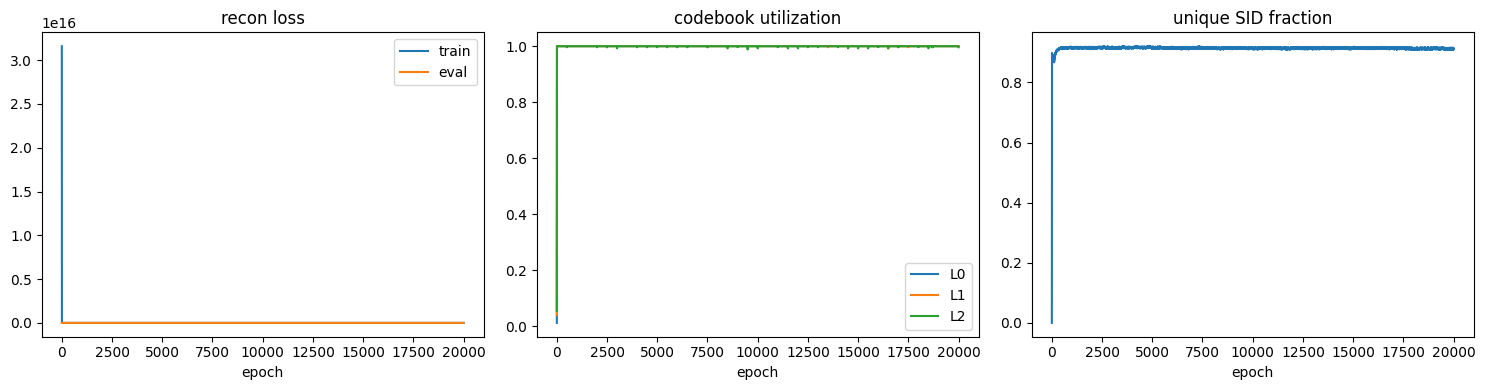

In [6]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, [h["train_recon"] for h in history], label="train")
axes[0].plot(epochs, [h["recon_loss"] for h in history], label="eval")
axes[0].set_title("recon loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
for l in range(len(history[0]["utilization"])):
    axes[1].plot(epochs, [h["utilization"][l] for h in history], label=f"L{l}")
axes[1].set_title("codebook utilization"); axes[1].set_xlabel("epoch"); axes[1].legend()
axes[2].plot(epochs, [h["sid_unique_fraction"] for h in history])
axes[2].set_title("unique SID fraction"); axes[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 3. Generate Semantic IDs

In [7]:
from src.generate_sids import generate

ckpt = Path(cfg["output"]["checkpoints_dir"]) / "best.pt"
generate(cfg, str(ckpt))

[gen] device=cuda
[gen] loaded outputs/amazon_beauty_checkpoints/best.pt  L=3 K=256
[gen] utilization per level: ['1.000', '1.000', '1.000']
[gen] perplexity per level:  ['242.82', '206.35', '204.86']
[gen] sid unique fraction:   0.9098  collisions=23375
[gen] wrote outputs/amazon_beauty_sids.csv  (259204 rows)

[sample] 10 items and their SIDs:
   148-107-232  {'item_id': '0205616461', 'title': 'Bio-Active Anti-Aging Serum (Firming Ultra-Hydrating Serum)', 'brand': nan, 'categories': 'Beauty, Skin Care, Face, Creams & Moisturizers', 'price': nan, 'description': 'As we age, our once youthful, healthy skin succumbs to an enzymatic imbalance that wears away the cellular network, resulting in skin thinning and aging. Combining the best of nature and cosmetic biotechnology, Bio-Active products are formulated with Enzymes that gently exfoliate the skin and stimulate regeneration for a youthful glow. Benefiting from fertile orchards in the Italian countryside, Bio-active formulas are rich in

In [8]:
import json
import pandas as pd

sids = pd.read_csv(cfg["output"]["sids_csv"])
print(f"{len(sids)} items")
display(sids.head(10))

with open(cfg["output"]["metrics_json"]) as f:
    print(json.dumps(json.load(f), indent=2))

259204 items


,item_id,title,brand,categories,price,description,sid
0,0205616461,Bio-Active Anti-Aging Serum (Firming Ultra-Hyd...,NaN,"Beauty, Skin Care, Face, Creams & Moisturizers",NaN,"As we age, our once youthful, healthy skin suc...",148-107-232
1,0558925278,Eco Friendly Ecotools Quality Natural Bamboo C...,NaN,"Beauty, Tools & Accessories, Makeup Brushes & ...",NaN,Mineral Powder Brush--Apply powder or mineral ...,151-189-146
2,0733001998,Mastiha Body Lotion,NaN,"Beauty, Skin Care, Body, Moisturizers, Lotions",NaN,"From the Greek island of Chios, this Mastiha b...",55-108-0
3,0737104473,Hello Kitty Lustre Lipstick (See sellers comme...,NaN,"Beauty, Makeup, Lips, Lipstick",NaN,Limited edition Hello Kitty Lipstick featuring...,246-35-169
4,0762451459,Stephanie Johnson Mermaid Round Snap Mirror,NaN,"Beauty, Tools & Accessories, Mirrors, Makeup M...",19.98,"The mermaid is an elusive (okay, mythical) cre...",3-241-217
5,1304139212,Set of 2 MAC Lip Care - Lip Pencil - Auburn,NaN,"Beauty, Makeup, Lips, Lip Liners",NaN,"A pencil designed for shaping, lining or filli...",90-233-131
6,130414674X,Set of 2 Benefit She Laq Makeup Sealer,NaN,"Beauty, Makeup, Makeup Sets",NaN,What it is:A magical makeup sealer. What it do...,195-11-239
7,130414089X,New Benefit Waterproof Automatic Eyeliner Pen ...,NaN,"Beauty, Makeup, Eyes, Eyeliner",NaN,Length : 13.5 cm\nColor: Black\n100% Brand new...,155-110-43
8,1304196062,Max Factor Lasting Performance Foundation -Pas...,NaN,"Beauty, Makeup, Face, Foundation",NaN,Lasting Performance Liquid Make-up feels natur...,242-189-131
9,1304146537,Set of 2 Goodskin Labs Eyliplex-2 Eye Life and...,NaN,"Beauty, Skin Care, Eyes, Dark Circle Treatments",NaN,Eyliplex-2 is a dual solution that focuses on ...,251-4-64


{
  "recon_loss": 9832037.417322835,
  "utilization": [
    1.0,
    1.0,
    0.99609375
  ],
  "perplexity": [
    243.1129150390625,
    207.82901000976562,
    221.50559997558594
  ],
  "sid_unique_fraction": 0.9127328281970957,
  "sid_collisions": 22620,
  "final_utilization": [
    1.0,
    1.0,
    1.0
  ],
  "final_perplexity": [
    242.8162078857422,
    206.3523406982422,
    204.85733032226562
  ],
  "final_sid_unique_fraction": 0.9098200645051774,
  "final_sid_collisions": 23375
}
